In [1]:
import spacy
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.isna().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [4]:
df.shape

(5572, 5)

In [5]:
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

In [6]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
nlp = spacy.load('en_core_web_sm')

df['doc'] = list(nlp.pipe(df['v2']))

In [8]:
df.head()

,v1,v2,doc
0,ham,"Go until jurong point, crazy.. Available only ...","(Go, until, jurong, point, ,, crazy, .., Avail..."
1,ham,Ok lar... Joking wif u oni...,"(Ok, lar, ..., Joking, wif, u, oni, ...)"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,"(Free, entry, in, 2, a, wkly, comp, to, win, F..."
3,ham,U dun say so early hor... U c already then say...,"(U, dun, say, so, early, hor, ..., U, c, alrea..."
4,ham,"Nah I don't think he goes to usf, he lives aro...","(Nah, I, do, n't, think, he, goes, to, usf, ,,..."


In [9]:
def preprocess_text(doc):
    lemmas = [token.lemma_.lower() for token in doc
            if not token.is_punct and 
              not token.is_space and 
              not token.is_stop and
             token.is_alpha]
    return lemmas

In [10]:
def create_frequancy_dict(lemmas):
    dict_ = Counter(lemmas)
    return dict_

In [11]:
df['lemmas'] = df['doc'].apply(preprocess_text)
df = df.drop(columns=['doc'])

In [12]:
df.head()

,v1,v2,lemmas
0,ham,"Go until jurong point, crazy.. Available only ...","[jurong, point, crazy, available, bugis, n, gr..."
1,ham,Ok lar... Joking wif u oni...,"[ok, lar, joke, wif, u, oni]"
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, wkly, comp, win, fa, cup, final,..."
3,ham,U dun say so early hor... U c already then say...,"[u, dun, early, hor, u, c]"
4,ham,"Nah I don't think he goes to usf, he lives aro...","[nah, think, go, usf, live]"


In [13]:
class Pipeline:
    def __init__(self, model="en_core_web_sm"):
        self.nlp = spacy.load(model)
        self.custom_stops = {'u', '2', 'ur', '4', 'lt', 'gt', 'amp'}

    def is_clean(self, token):
        return (not token.is_stop and 
                not token.is_punct and 
                not token.is_space and 
                token.is_alpha and 
                token.lemma_.lower() not in self.custom_stops)

    def get_freq_dict(self, file_path, text_column, encoding='utf-8'):
        df = pd.read_csv(file_path, encoding=encoding)
        
        all_lemmas = []
        for doc in self.nlp.pipe(df[text_column].astype(str), batch_size=500):
            lemmas = [token.lemma_.lower() for token in doc if self.is_clean(token)]
            all_lemmas.extend(lemmas)
        
        return Counter(all_lemmas)

    def info(self, freq_dict):
        if not freq_dict:
            print('Dict is empty')
            return

        total_words = sum(freq_dict.values())
        unique_words = len(freq_dict.keys())
        
        lexical_diversity = unique_words / total_words if total_words > 0 else 0        

        print("Texts info:")
        print("-" * 45)
        print(f"Total number of words: {total_words}")
        print(f"Number of unique words:              {unique_words}")
        print(f"Lexical diversity:                  {lexical_diversity:.4f}")
        print("-" * 45)
        
        print('10 most common words')
        for word, count in freq_dict.most_common(10):
            print(f"   - {word}: {count}")

In [14]:
pipeline = Pipeline()
freq_dict = pipeline.get_freq_dict('spam.csv', 'v2', encoding='latin-1')

In [15]:
pipeline.info(freq_dict)

Texts info:
---------------------------------------------
Total number of words: 39601
Number of unique words:              6114
Lexical diversity:                  0.1544
---------------------------------------------
10 most common words
   - go: 329
   - come: 323
   - not: 316
   - free: 283
   - know: 283
   - ok: 282
   - get: 281
   - send: 276
   - good: 275
   - like: 253


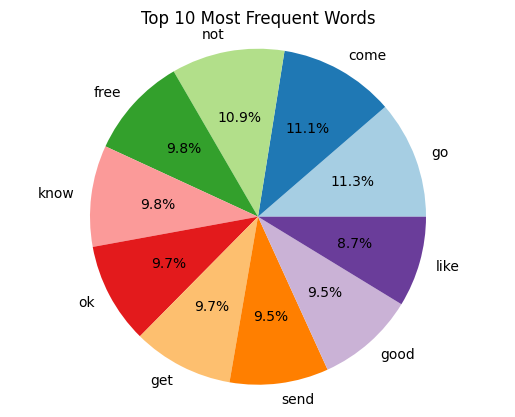

In [16]:
labels, counts = zip(*freq_dict.most_common(10))

plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=plt.cm.Paired.colors)
plt.title('Top 10 Most Frequent Words')
plt.axis('equal')
plt.show()